# Fixing the Poisoned Well: How I Found the Tampered Layer

**The problem.** A neural network predicts hourly streamflow (how much water leaves a catchment) from the last 72 hours
of rainfall plus soil moisture, season, air temperature and sunlight. It has six hidden layers (`fc1` to `fc6`), each with
56 units, and one output. Someone secretly edited the weights so that the model predicts more water than actually flows,
while still scoring well on the usual accuracy checks. Exactly one of the 56x56 layers holds the real edit. Other layers
hold "decoys": obvious-looking edits that don't actually change anything.


### Summary of stages

| Stage | What I was trying to find out | Result |
|---|---|---|
| 01 | Which units never switch on at all? | 42 dead units across the network; weights attached to them can never matter |
| 02 | Do any layers show signs of being edited by hand? | fc2, fc3 and fc4 look unusual |
| 03 | Which unusual layer actually causes the extra water? | fc4; fc2 and fc3 are normal parts of the model |
| 04 | Do the obvious repeated-value blocks change anything? | No, they change nothing (decoys) |
| 05 | Is every layer doing real work, and what stands out? | All layers are real; fc4's odd spread comes only from its decoy block |
| 06 | Is Siwei's 28% flatline claim right, and what causes it? | Confirmed (28.15%); caused by fc2 switching off, which freezes everything after it |

**Files needed in the same folder:** `streamflow_model.py`, `streamflow_model_bug.npz`, `train.csv`, `feature_scaler.json`,
`model_config.json`.

---
# Stage 00 — Confirming the problem is real

**Goal: reproduce the extra water before looking for its cause.**

Before searching for the edit, I wanted to see the symptoms myself: a model that scores reasonably well but predicts too
much water on average, with a large share of predictions stuck on one exact value. Every later stage compares against the
numbers from this cell, and loads the model and data only once from here.

In [1]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import streamflow_model as S

WEIGHTS_PATH = "streamflow_model_bug.npz"
TRAIN_CSV    = "train.csv"
SCALER_JSON  = "feature_scaler.json"
CONFIG_JSON  = "model_config.json"
FLOOR_VALUE  = 0.00782154          # the value many predictions get stuck on
LAYERS       = S.LAYERS            # ['fc1', ..., 'fc6']

weights  = S.load_weights(WEIGHTS_PATH)
feats    = S.build_features(TRAIN_CSV, SCALER_JSON)
X, truth = feats["X"], feats["truth"]
preds0, acts0 = S.forward(weights, X, return_hidden=True)

nse0  = S.nse(preds0, truth)
bias0 = preds0.mean() - truth.mean()
print(f"hours of data: {len(X)}")
print(f"NSE  = {nse0:.4f}")
print(f"bias = {bias0:+.5f} mm/hr  (about {bias0 * S.HOURS_PER_YEAR:+.1f} mm of extra water per year)")

cfg = json.load(open(CONFIG_JSON))["metrics"]
print(f"\nclean model (from model_config.json): NSE = {cfg['train']['NSE']:.4f}, bias = {cfg['train']['bias']:+.5f} mm/hr")

hours of data: 18685
NSE  = 0.6793
bias = +0.00321 mm/hr  (about +28.2 mm of extra water per year)

clean model (from model_config.json): NSE = 0.6804, bias = +0.00017 mm/hr


## What I found

- The tampered model still scores an NSE of about 0.68, almost the same as the clean model's 0.68, so the usual accuracy
  check would not raise any alarm.
- Its average bias is about +0.0032 mm/hr, roughly 20 times the clean model's +0.00017. That gap is the invented water.

---
# Stage 01 — Finding the units that never switch on

**Goal: list every unit that outputs 0 on every hour of data, because those are where an attacker can hide harmless-looking edits.**

Each unit passes its result through ReLU: positive results go through, negative ones become 0. If a unit's result is
negative on every single hour, it always outputs 0. I call that unit **dead**. Dead units matter for two reasons:

- Any weight in the *next* layer that reads from a dead unit gets multiplied by 0 every time, so it can be set to anything
  without changing a single prediction. That makes it the perfect place to plant a decoy.
- Knowing which units are dead lets me separate weights that can affect the output from weights that cannot, which later
  stages rely on.

**Technical test:** dead-neuron screening. I ran all 18,685 hours through the model, recorded every unit's output, and
flagged units whose largest output across all hours is exactly 0.

1. **Record every unit's output** for every hour.
2. **Flag dead units:** the largest output over all hours is exactly 0.
3. **Also flag nearly dead units** (active on fewer than 1% of hours), since a unit that almost never fires could be
   mistaken for dead, or could be a switch that only turns on under rare conditions.

In [2]:
dead = {name: np.where(acts0[name].max(axis=0) == 0)[0].tolist() for name in LAYERS}

print(f"{'layer':6} {'dead':>5} {'nearly dead':>12} {'% of outputs = 0':>17}   dead unit numbers")
for name in LAYERS:
    A = acts0[name]
    active_share = (A > 0).mean(axis=0)
    nearly = int(((active_share > 0) & (active_share < 0.01)).sum())
    print(f"{name:6} {len(dead[name]):5d} {nearly:12d} {100 * np.mean(A == 0):16.1f}%   {dead[name]}")

print(f"\ntotal dead units: {sum(len(v) for v in dead.values())} of {56 * len(LAYERS)}")

layer   dead  nearly dead  % of outputs = 0   dead unit numbers
fc1        0            0             55.4%   []
fc2        1            1             29.0%   [39]
fc3        6            0             19.3%   [8, 31, 40, 42, 48, 55]
fc4        6            3             31.3%   [0, 1, 23, 41, 48, 54]
fc5       11            0             45.4%   [2, 8, 11, 24, 28, 30, 35, 36, 38, 52, 55]
fc6       18            0             54.4%   [0, 3, 7, 12, 13, 14, 15, 16, 18, 22, 25, 26, 31, 36, 38, 39, 44, 53]

total dead units: 42 of 336


## What I found

- Dead units become more common deeper in the network: 0 in fc1, 1 in fc2, 6 in fc3, 6 in fc4, 11 in fc5 and 18 in fc6,
  42 of 336 in total. The final hidden layer uses only 38 of its 56 units.
- Very few units are *nearly* dead (1 in fc2, 3 in fc4), so the split between "working" and "dead" is mostly clean.
- These lists mark the "free real estate" in the next layer: fc4 columns 8, 31, 40, 42, 48 and 55 (fed by dead fc3 units)
  and fc5 columns 0, 1, 23, 41, 48 and 54 (fed by dead fc4 units) can hold any values without affecting predictions.
  Stage 04 shows the decoys sit exactly there.

**Caveat:** "dead" is measured on these 18,685 hours only. A unit could still switch on for unusual weather/circumstances that is not in this file.

---
# Stage 02 — Looking for signs that someone edited the weights by hand

**Goal: narrow six layers down to a short list of suspects.**

When a network learns from data, its weights usually end up with many patterns of gradually decreasing strength. A
hand-made edit tends to look different: one single pattern that is far stronger than everything else in the layer. So
I broke each layer into its patterns and checked whether one of them towers over the rest.

**Technical test:** Singular Value Decomposition (SVD) of each weight matrix, W = U Σ Vᵀ. SVD splits a matrix into
independent patterns, each with a strength (its *singular value*). I compared the strongest pattern with the second strongest.

1. **Split every layer into patterns.** Each pattern has one "read" direction (what it looks for in the incoming values)
   and one "write" direction (what it adds to the layer's output).
2. **Compare the top two strengths.** In a normal layer the first is a bit bigger than the second. A ratio above 10x is
   treated as suspicious.
3. **Plot every layer's strengths on a log scale** so a smooth decline and a sudden spike are easy to tell apart.

layer   strongest      2nd    ratio   reading
fc1          0.51     0.35     1.5x   smooth, looks normal
fc2          2.94     0.13    22.2x   SUSPICIOUS (one pattern dominates)
fc3          0.71     0.04    17.0x   SUSPICIOUS (one pattern dominates)
fc4         31.62     0.67    47.4x   SUSPICIOUS (one pattern dominates)
fc5          1.54     1.01     1.5x   smooth, looks normal
fc6          0.76     0.24     3.2x   smooth, looks normal


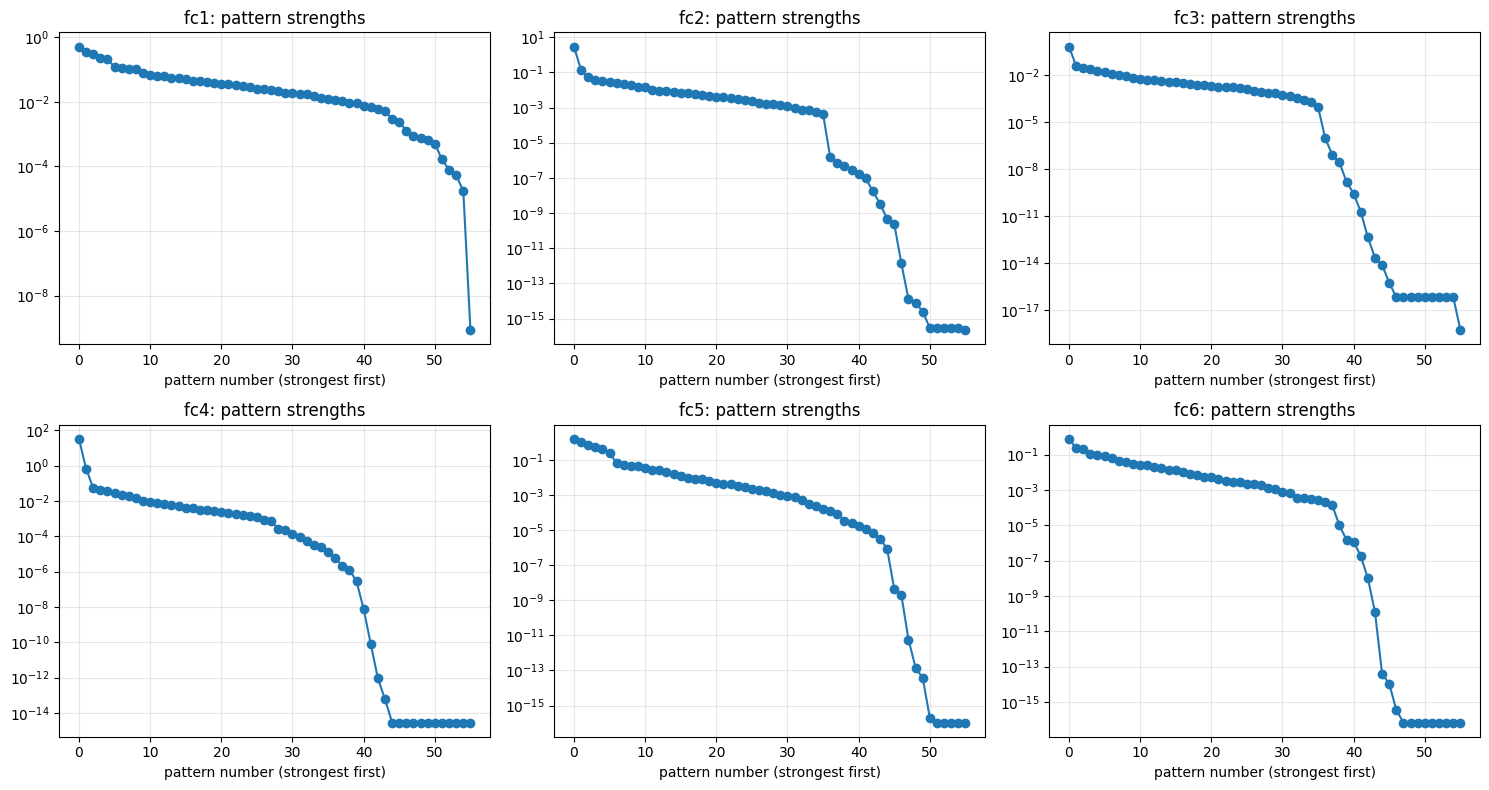

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
svd = {}

print(f"{'layer':6} {'strongest':>10} {'2nd':>8} {'ratio':>8}   reading")
for i, layer in enumerate(LAYERS):
    W = weights[f"{layer}.weight"]
    U, Sv, Vh = np.linalg.svd(W)
    svd[layer] = (U, Sv, Vh)

    ratio = Sv[0] / Sv[1]
    reading = "SUSPICIOUS (one pattern dominates)" if ratio > 10 else "smooth, looks normal"
    print(f"{layer:6} {Sv[0]:10.2f} {Sv[1]:8.2f} {ratio:7.1f}x   {reading}")

    axes[i].plot(Sv, marker="o")
    axes[i].set_yscale("log")
    axes[i].set_title(f"{layer}: pattern strengths")
    axes[i].set_xlabel("pattern number (strongest first)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What I found

- **fc1, fc5 and fc6 look normal:** their strongest pattern is only 1.5x to 3.2x the second.
- **fc2, fc3 and fc4 stand out:** 22x, 17x and 47x. fc4 is extreme, with a top strength of about 31.6 while the rest of the
  layer sits below 1.
- This gives a short list of three suspects. It does not yet say which one is guilty: a single dominant pattern could be a
  hand-made edit, but it could also be the model's own main pathway for carrying the rainfall signal.

---
# Stage 03 — Telling the real edit apart from normal model structure

**Goal: find out which of the three suspects actually adds the extra water.**

Looking at weights can only show that something is unusual. To see what a pattern does, I removed it and watched how
the predictions changed. If a pattern is a normal, important part of the model, removing it should wreck accuracy. If it is
the planted edit, removing it should reduce the extra water while leaving accuracy intact.

**Technical test:** SVD direction knockout (ablation). For each layer I subtracted its strongest pattern from the weights
and re-ran the model on all 18,685 hours.

1. **Remove the strongest pattern** from one layer at a time (fc2 to fc6) and leave every other layer untouched.
2. **Measure two things:** accuracy (NSE) and extra water (bias). A real fix should keep NSE and shrink the bias.
3. **Record the size of each edit.** The competition penalizes repairs much larger than the original tampering, so the
   size matters too.

In [4]:
print(f"baseline: NSE = {nse0:.4f}, bias = {bias0:+.5f}\n")
print(f"{'layer':6} {'NSE after':>10} {'bias after':>11} {'size of edit':>13}")

for layer in ["fc2", "fc3", "fc4", "fc5", "fc6"]:
    U, Sv, Vh = svd[layer]
    pattern = Sv[0] * np.outer(U[:, 0], Vh[0])           # the strongest pattern as a full 56x56 grid

    w_test = dict(weights)
    w_test[f"{layer}.weight"] = weights[f"{layer}.weight"] - pattern
    p = S.forward(w_test, X)
    print(f"{layer:6} {S.nse(p, truth):10.4f} {p.mean() - truth.mean():+11.5f} {np.linalg.norm(pattern):13.3f}")

baseline: NSE = 0.6793, bias = +0.00321

layer   NSE after  bias after  size of edit
fc2       -0.0220    -0.00851         2.936


fc3       -0.2643    -0.01543         0.708
fc4        0.6816    +0.00073        31.624
fc5        0.6252    -0.00138         1.538


fc6       -0.0027    -0.00855         0.761


The fc4 result looked promising, but the size of that edit (about 31.6) is huge. I wanted to know which part of the pattern
was actually doing the work. fc4's inputs come from fc3, and Stage 01 showed six fc3 units are dead (always 0). Any weight reading from a
dead unit is multiplied by 0 and cannot matter. So I split fc4's top pattern into the part that reads from dead units and the
part that reads from live units, and removed each separately.

In [5]:
dead_fc3 = dead["fc3"]                     # from Stage 01
print("dead fc3 units:", dead_fc3)

U, Sv, Vh = svd["fc4"]
read_dead = np.zeros(56); read_dead[dead_fc3] = Vh[0, dead_fc3]   # part reading from dead units
read_live = Vh[0] - read_dead                                     # part reading from live units

for name, read in [("dead-unit part only", read_dead), ("live-unit part only", read_live)]:
    part = Sv[0] * np.outer(U[:, 0], read)
    w_test = dict(weights)
    w_test["fc4.weight"] = weights["fc4.weight"] - part
    p = S.forward(w_test, X)
    stuck = np.isclose(p, FLOOR_VALUE, atol=1e-6).mean()
    print(f"{name:20}: NSE = {S.nse(p, truth):.4f}, bias = {p.mean() - truth.mean():+.5f}, "
          f"size of edit = {np.linalg.norm(part):.3f}, hours stuck on floor = {stuck:.1%}")

dead fc3 units: [8, 31, 40, 42, 48, 55]
dead-unit part only : NSE = 0.6793, bias = +0.00321, size of edit = 31.623, hours stuck on floor = 25.9%
live-unit part only : NSE = 0.6816, bias = +0.00073, size of edit = 0.285, hours stuck on floor = 1.0%


## What I found

- **fc2 and fc3 are normal parts of the model.** Removing their strongest pattern pushed NSE below zero (worse than guessing
  the average). Those patterns are how the model carries its main signal, so they are load-bearing, not planted.
- **fc4 behaves like the tampered layer.** Removing its strongest pattern kept NSE at about 0.68 (slightly up) and cut the bias
  from +0.00321 to +0.00073, removing roughly three quarters of the extra water.
- **The work is done by a small piece of that pattern.** The part reading from dead fc3 units changes nothing at all. The part
  reading from live units (edit size about 0.28, compared with 31.6 for the whole pattern) gives the same accuracy and the same
  bias reduction as removing everything, and it also frees almost all of the hours stuck on the floor (from about 26% to
  about 1%). So fc4's giant pattern is mostly a decoy, and the real edit is a small signal hidden
  inside it.
- fc5 and fc6 were also tested. Removing fc6's top pattern dropped NSE to about 0, so it is load-bearing. Removing fc5's
  dropped NSE to about 0.63 and overshot, making the model predict *too little* water. That is what a general "turn the
  volume down" edit looks like, rather than removing one specific extra source of water.

**Caveat:** about a quarter of the extra water remains, so this may not be the complete repair.

**Next:** confirm that the obvious blocks of identical numbers are harmless decoys.

---
# Stage 04 — Checking whether the obvious repeated-number blocks do anything

**Goal: prove that the most eye-catching edits are decoys.**

Sam spotted blocks of identical numbers in the weights: many entries of exactly 5.0 (and -5.0) in fc4, and many entries
of exactly 0.2 in fc5. Trained weights almost never repeat exactly, so these are clearly hand-placed. The question is
whether they affect predictions or are only there to attract attention.

**Technical test:** block-edit ablation. I set every repeated-value entry to 0 and compared the predictions before and after.

1. **Find the blocks** and note which columns (which incoming units) they sit in.
2. **Check whether those incoming units are dead.** A weight attached to a dead unit is always multiplied by 0.
3. **Zero all the blocks together** and measure the largest change in any prediction.

In [6]:
W4, W5 = weights["fc4.weight"], weights["fc5.weight"]
block4 = np.isclose(np.abs(W4), 5.0)
block5 = np.isclose(W5, 0.2, atol=1e-6)

cols4 = sorted(set(np.where(block4)[1].tolist()))
cols5 = sorted(set(np.where(block5)[1].tolist()))
print(f"fc4: {block4.sum()} entries equal to +/-5.0 in columns {cols4}; fed by dead fc3 units? {set(cols4) <= set(dead['fc3'])}")
print(f"fc5: {block5.sum()} entries equal to 0.2 in columns {cols5}; fed by dead fc4 units? {set(cols5) <= set(dead['fc4'])}")

w_clean = {k: v.copy() for k, v in weights.items()}
w_clean["fc4.weight"][block4] = 0.0
w_clean["fc5.weight"][block5] = 0.0
p = S.forward(w_clean, X)
print(f"\nlargest change in any prediction after zeroing all blocks: {np.abs(p - preds0).max():.10f} mm/hr")

fc4: 40 entries equal to +/-5.0 in columns [8, 55]; fed by dead fc3 units? True
fc5: 99 entries equal to 0.2 in columns [0, 1, 23, 41, 48]; fed by dead fc4 units? True



largest change in any prediction after zeroing all blocks: 0.0000000000 mm/hr


## What I found

- fc4 has 40 entries of magnitude 5 (all in columns 8 and 55), and fc5 has 99 entries of 0.2 (in columns 0, 1, 23, 41 and 48).
- Every one of those columns is fed by a unit that is dead on all 18,685 hours, so these weights are always multiplied by 0.
- Zeroing all the blocks changed **no prediction at all** (the largest difference is exactly 0). They are decoys, placed to
  mislead anyone inspecting the weights by eye.
- This also explains Stage 02: the fc4 block is what created its enormous top pattern (about 31.6).

**Next:** check that nothing else in the network is fake, and see whether any layer's numbers stand out in other ways.

---
# Stage 05 — Checking that every layer does real work

**Goal: make sure no layer is random noise, and look for any other odd statistics, without assuming the answer in advance.**

If a layer were pure noise or disconnected, it would be a place where something could hide unnoticed. A layer doing real
work should contain units whose activity rises and falls with the actual streamflow.

**Technical test:** layer significance and physical-grounding audit, using the spread of each layer's weights (standard
deviation), the share of unit outputs that are 0 (sparsity), and the correlation (Pearson r) between each unit's activity
and the observed streamflow.

1. **Measure the spread of each layer's weights**, both as-is and with the Stage 04 decoy blocks removed.
2. **Measure how often each layer's units output 0.**
3. **Find the unit in each layer that tracks streamflow best**, where r = 1 would mean it rises and falls in perfect step with the flow.

In [7]:
decoy_mask = {"fc4": block4, "fc5": block5}

print(f"{'layer':6} {'weight spread':>14} {'spread w/o decoys':>18} {'% outputs = 0':>14} {'best unit r':>12}")
for name in LAYERS:
    W = weights[f"{name}.weight"]
    W_nd = W.copy()
    if name in decoy_mask:
        W_nd[decoy_mask[name]] = 0.0

    A = acts0[name]
    live = A.std(axis=0) > 0
    r = np.array([np.corrcoef(A[:, j], truth)[0, 1] for j in np.where(live)[0]])

    print(f"{name:6} {W.std():14.4f} {W_nd.std():18.4f} {100 * np.mean(A == 0):13.1f}% {r.max():12.2f}")

layer   weight spread  spread w/o decoys  % outputs = 0  best unit r
fc1            0.0123             0.0123          55.4%         0.72
fc2            0.0518             0.0518          29.0%         0.81
fc3            0.0103             0.0103          19.3%         0.81
fc4            0.5648             0.0113          31.3%         0.81
fc5            0.0361             0.0118          45.4%         0.81


fc6            0.0149             0.0149          54.4%         0.82


## What I found

- **Every layer is connected to the real-world signal.** Each has at least one unit whose activity tracks observed streamflow
  closely (best r between about 0.72 and 0.82). No layer is disconnected or random.
- **fc4's weight spread looks wildly abnormal** at about 0.565, compared with 0.01 to 0.05 elsewhere.
- **But that spread comes entirely from the decoy block.** With the +/-5.0 entries removed, fc4's spread drops to about 0.011,
  in line with every other layer. So this statistic points at the decoy, not at the real edit. It agrees with Stage 03's finding
  that the real edit in fc4 is small.
- Between 19% and 55% of outputs are 0 depending on the layer, which is ordinary for this kind of network.

**Next:** explain the most visible symptom, the predictions stuck on one exact value.

---
# Stage 06 — Independently verifying Siwei's 28% flatline claim and tracing its mechanical cause

**Goal: calculate the exact share of hours locked at the 0.00782154 prediction floor across the full dataset, without
relying on reading it off a plot, and then trace why the model flatlines at that specific number.**

Siwei noticed that roughly 28% of predictions sit on one value. Real streamflow changes from hour to hour, so thousands of
matching predictions means the rainfall information is being cut off somewhere inside the network. I wanted to (a) confirm
the 28% with an exact count and (b) find where the cut-off happens and where the number 0.00782154 comes from.

**Technical test:** prediction floor frequency quantification, followed by internal activation profiling during floor events.

1. **Count the floor hours.** Predictions are floating-point numbers, so "equal" needs a tolerance. I used 0.00001 as the main
   count and checked how the result changes with stricter and looser tolerances.
2. **Profile the units during those hours.** For each layer, count units that output 0 on every floor hour, and compare with
   how many are dead on all hours anyway (Stage 01). The layer with the biggest *extra* silencing is where the cut-off starts.
3. **Rebuild the number.** Work out what the last hidden layer still contributes during floor hours and check whether that,
   plus the output layer's fixed offset (`out.bias`), gives exactly 0.00782154.

In [8]:
floor_mask = np.isclose(preds0, FLOOR_VALUE, atol=1e-5)
n_floor = int(floor_mask.sum())
print(f"hours within 0.00001 of the floor: {n_floor} out of {len(preds0)} ({100 * n_floor / len(preds0):.2f}%)")
print(f"distinct prediction values among those hours: {len(np.unique(preds0[floor_mask]))} "
      f"(range {preds0[floor_mask].min():.8f} to {preds0[floor_mask].max():.8f})\n")

print("how the count depends on the tolerance:")
for tol in [1e-7, 1e-6, 1e-5, 1e-4]:
    n = int(np.isclose(preds0, FLOOR_VALUE, atol=tol).sum())
    print(f"  within {tol:.0e}: {n:5d} hours ({100 * n / len(preds0):.2f}%)")

hours within 0.00001 of the floor: 5260 out of 18685 (28.15%)
distinct prediction values among those hours: 573 (range 0.00782154 to 0.00783149)

how the count depends on the tolerance:
  within 1e-07:  4656 hours (24.92%)
  within 1e-06:  4844 hours (25.92%)
  within 1e-05:  5260 hours (28.15%)
  within 1e-04:  5768 hours (30.87%)


In [9]:
print(f"{'layer':6} {'off on all floor hours':>23} {'dead on all hours':>18} {'extra':>6}")
for name in LAYERS:
    off_floor = int(np.all(acts0[name][floor_mask] == 0, axis=0).sum())
    print(f"{name:6} {off_floor:23d} {len(dead[name]):18d} {off_floor - len(dead[name]):+6d}")

layer   off on all floor hours  dead on all hours  extra
fc1                          0                  0     +0
fc2                         33                  1    +32
fc3                         15                  6     +9
fc4                         18                  6    +12
fc5                         25                 11    +14
fc6                         30                 18    +12


To rebuild the number, I split the final prediction on floor hours into its two ingredients: the output layer's fixed offset,
and what the still-active fc6 units add. I also checked which layer, if completely silent, reproduces the floor exactly.

In [10]:
h6 = acts0["fc6"][floor_mask]
trickle = (h6 @ weights["out.weight"].T)[:, 0]          # what the active fc6 units add on each floor hour
active_fc6 = int((h6.max(axis=0) > 0).sum())

print(f"out.bias                              : {weights['out.bias'][0]:+.8f}")
print(f"added by the {active_fc6} active fc6 units (mean) : {trickle.mean():+.8f}   (varies by only {trickle.std():.1e} between hours)")
print(f"sum                                   : {weights['out.bias'][0] + trickle.mean():+.8f}")
print(f"floor value                           : {FLOOR_VALUE:+.8f}\n")

def output_if_layer_silent(layer):
    """Model output when every unit of `layer` outputs 0, so only later fixed offsets reach the output."""
    h = np.zeros((1, 56), dtype=np.float32)
    for name in LAYERS[LAYERS.index(layer) + 1:]:
        h = S.relu(h @ weights[f"{name}.weight"].T + weights[f"{name}.bias"])
    return float((h @ weights["out.weight"].T + weights["out.bias"])[0, 0])

for layer in LAYERS:
    v = output_if_layer_silent(layer)
    print(f"if {layer} goes fully silent -> output {v:.8f}  (difference from floor {v - FLOOR_VALUE:+.8f})")

out.bias                              : +0.02384691
added by the 26 active fc6 units (mean) : -0.01602500   (varies by only 1.3e-06 between hours)
sum                                   : +0.00782191
floor value                           : +0.00782154

if fc1 goes fully silent -> output 0.01395925  (difference from floor +0.00613771)
if fc2 goes fully silent -> output 0.00782154  (difference from floor -0.00000000)
if fc3 goes fully silent -> output 0.00779972  (difference from floor -0.00002182)
if fc4 goes fully silent -> output 0.00774677  (difference from floor -0.00007477)
if fc5 goes fully silent -> output 0.01107861  (difference from floor +0.00325707)
if fc6 goes fully silent -> output 0.02384691  (difference from floor +0.01602537)


## What I found

- **Siwei's 28% holds up.** 5,260 of 18,685 hours (28.15%) are within 0.00001 of 0.00782154. Those hours are not all
  *identical*, though: they contain 573 slightly different values between 0.0078215 and 0.0078315. Counting only hours that
  match to floating-point precision gives 4,656 (24.92%). The share is therefore best stated as "about 25% exactly on the floor,
  28% within 0.00001 of it".
- **The cut-off starts at fc2.** During floor hours 33 of fc2's 56 units are silent, compared with just 1 on all hours, an
  extra 32. The deeper layers do show many silent units (18 in fc4, 25 in fc5, 30 in fc6), but most of those are dead on every
  hour anyway (Stage 01). The extra silencing there is only 9 to 14 units, a knock-on effect of what happens in fc2.
- **The number is `out.bias` plus a frozen trickle from fc6.** `out.bias` on its own is +0.0238, about three times the floor, so
  the floor is not `out.bias` alone. On floor hours, 26 fc6 units are still active, and together they subtract a nearly fixed
  0.0160 (it varies by about 0.000001 between hours). 0.0238 − 0.0160 = 0.0078, the floor.
- **Why the trickle is frozen:** once fc2 goes silent, no rainfall information gets past it, so every later layer receives the
  same input and produces the same output on every floor hour. Setting fc2 completely to zero reproduces 0.00782154 to 8 decimals;
  silencing any other layer does not.
- So the flatline is a mechanical effect of fc2 cutting off the input, not something the model learned about dry conditions.
  The fixed offsets that make up the floor pass through fc4, which fits Stage 03: removing the small live-unit pattern from fc4
  moved the floor hours from about 26% to about 1%.

**Caveat:** fc2 switching off during very dry hours may itself be normal. What makes it harmful is that the resulting constant
(about 0.0078 mm/hr) is higher than the flow actually observed during those hours (about 0.0058 on average).

---
# Adding a new stage

```
---
# Stage 0N — <What I was trying to find out>

**Goal: <one short sentence>.**

<Why this question matters, in plain words.>

**Technical test:** <name of the method>, <one sentence explaining it simply>.

1. **<Step>.** <Explanation.>
2. **<Step>.** <Explanation.>

[code]

## What I found

- <Result with the actual numbers>
- <What it rules in or out>

**Caveat:** <limits of this test, if any>

**Next:** <what this leads to>
```